# ML - Final Project
## Evaluation
**Project:** Multilingual Language Identification System

**Group Members:** 
1. Seyyed Sina Alizadeh Tabatabai - 810101477
2. Majid Sadeghinejad - 810101459
3. Matin Shiasi - 810101453

## 1. Introduction
This final notebook focuses on the rigorous evaluation of both the supervised (Classification) and unsupervised (Clustering) machine learning models.

**Objectives:**
1.  Classification Evaluation:
    *   Metric Calculation: Compute Accuracy, Precision, Recall, and F1-Score to quantify model performance.
    *   Error Analysis: Visualize Confusion Matrices to identify specific misclassifications (e.g., distinguishing between Spanish and Italian).
    *   Model Comparison: Benchmarking SVM, Random Forest, and MLP against each other.

2.  Clustering Evaluation:
    *   Silhouette Score: Measure how similar an object is to its own cluster compared to other clusters.
    *   Cluster Purity Analysis: Analyze the composition of each cluster to determine if languages naturally group together.

We utilize the pre-trained models (.pkl files) and the processed result files to ensure evaluation reflects the exact state of the trained systems.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, silhouette_score
from sklearn.model_selection import GroupShuffleSplit

sns.set_style("whitegrid")


DATA_FILE = '../Output/CSV/extracted_features.csv'
MODELS = {
    'SVM': '../Output/PKL/svm_model.pkl',
    'Random Forest': '../Output/PKL/rf_model.pkl',
    'MLP (Neural Net)': '../Output/PKL/mlp_model.pkl'
}
SCALER_FILE = '../Output/PKL/scaler.pkl'
ENCODER_FILE = '../Output/PKL/label_encoder.pkl'
RANDOM_STATE = 42

print("Libraries imported.")


Libraries imported.


## 2. Data Loading and Test Set Reconstruction
To ensure a fair evaluation, we must reconstruct the exact Test Set used during training.
*   We load the full dataset.
*   We apply the same GroupShuffleSplit (based on Student ID) with the same random_state. This guarantees that the X_test we generate here is identical to the "unseen" data the models were validated against.
*   We load the saved StandardScaler to transform the test data, ensuring the features are in the same numerical range as the training data.


In [20]:
df = pd.read_csv(DATA_FILE)


df['student_id'] = df['filename'].apply(lambda x: x.replace('noise_', '').split('_')[0])
groups = df['student_id']


X = df.drop(columns=['filename', 'label', 'gender', 'type', 'student_id'])
y = df['label']


le = joblib.load(ENCODER_FILE)
y_encoded = le.transform(y)


gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y_encoded, groups=groups))


X_test = X.iloc[test_idx]
y_test = y_encoded[test_idx]


scaler = joblib.load(SCALER_FILE)
X_test_scaled = scaler.transform(X_test)

print(f"Test Set Loaded: {X_test_scaled.shape[0]} samples")
print(f"Classes: {le.classes_}")


Test Set Loaded: 298 samples
Classes: ['German' 'Italian' 'Korean' 'Spanish']


## 3. Evaluation Metrics
We iterate through each saved model, generate predictions on the test set, and calculate the following metrics:
*   Accuracy: Overall percentage of correct predictions.
*   Precision: exactness (low false positives).
*   Recall: sensitivity (low false negatives).
*   F1-Score: Harmonic mean of Precision and Recall (crucial for balanced evaluation).


In [26]:
results = []

for model_name, file_path in MODELS.items():
    print(f"Evaluating {model_name}...")
    
    model = joblib.load(file_path)
    
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
    
    results.append({
        'Model': model_name,
        'Accuracy': acc,
        'F1-Score': f1,
        'Precision (Weighted)': report['weighted avg']['precision'],
        'Recall (Weighted)': report['weighted avg']['recall']
    })
    
    print(f"\n--- Classification Report: {model_name} ---")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

results_df = pd.DataFrame(results).set_index('Model')


Evaluating SVM...

--- Classification Report: SVM ---
              precision    recall  f1-score   support

      German       0.92      1.00      0.96        56
     Italian       0.53      0.73      0.61        52
      Korean       0.97      0.76      0.85       150
     Spanish       0.83      1.00      0.91        40

    accuracy                           0.83       298
   macro avg       0.81      0.87      0.83       298
weighted avg       0.87      0.83      0.84       298

Evaluating Random Forest...

--- Classification Report: Random Forest ---
              precision    recall  f1-score   support

      German       0.59      1.00      0.74        56
     Italian       0.50      0.73      0.59        52
      Korean       1.00      0.58      0.73       150
     Spanish       1.00      1.00      1.00        40

    accuracy                           0.74       298
   macro avg       0.77      0.83      0.77       298
weighted avg       0.84      0.74      0.75       298

Ev

## 4. Confusion Matrix Analysis
The Confusion Matrix is the most powerful tool for diagnosing model errors. It shows us exactly where the model is confused.
*   Diagonal: Correct predictions.
*   Off-Diagonal: Errors.
*   Hypothesis: We expect to see confusion between Spanish and Italian due to their linguistic similarity (Romance languages) and the clustering results observed in the previous phase.


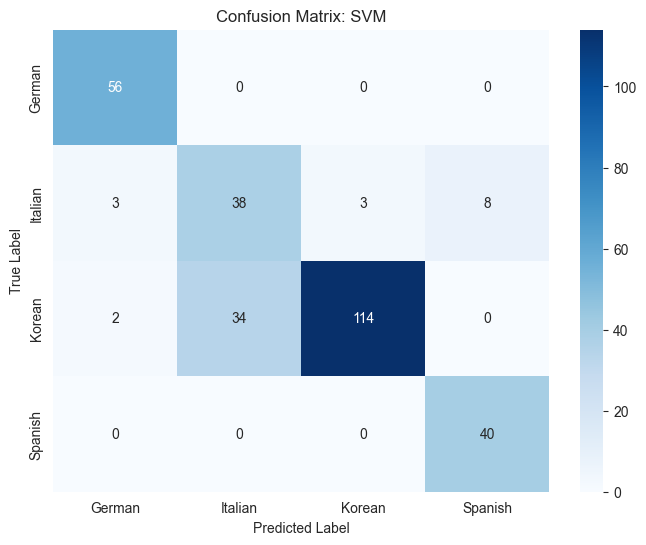

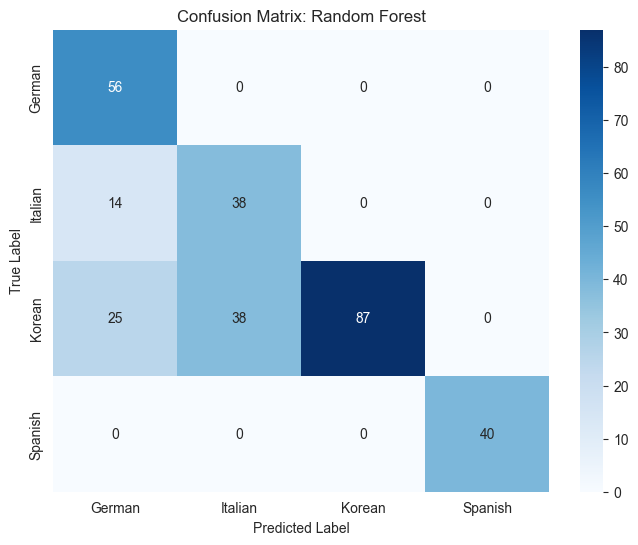

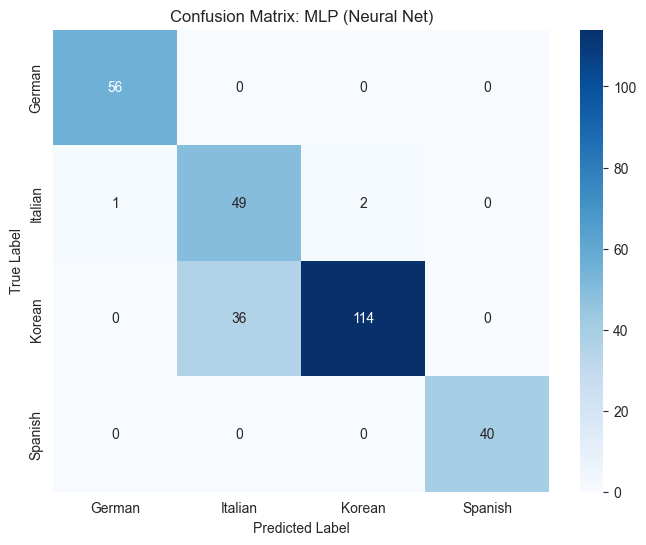

In [29]:
def plot_confusion_matrix(model_path, title):
    model = joblib.load(model_path)
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

for model_name, file_path in MODELS.items():
    plot_confusion_matrix(file_path, f'Confusion Matrix: {model_name}')


## 5. Model Comparison and Conclusion
We visualize the performance comparison to determine the superior model.


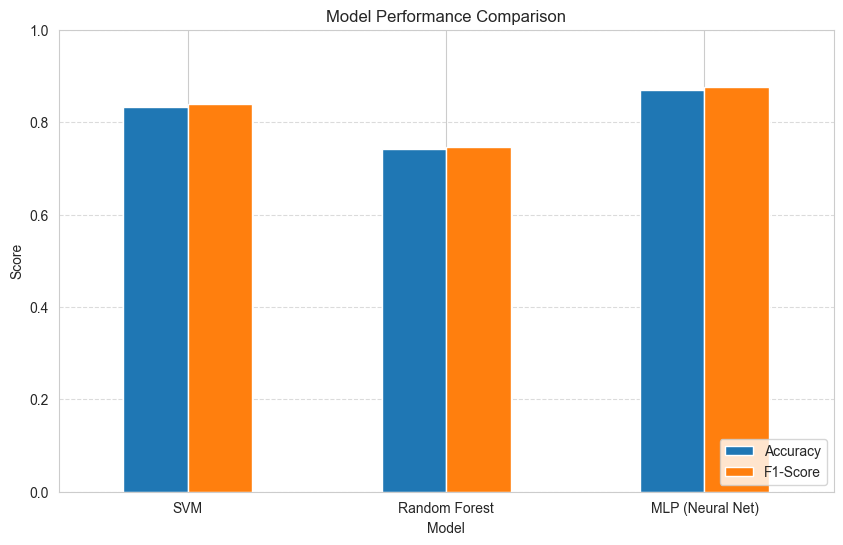

Summary of Results:
                  Accuracy  F1-Score  Precision (Weighted)  Recall (Weighted)
Model                                                                        
SVM               0.832215  0.838696              0.866918           0.832215
Random Forest     0.741611  0.746772              0.835606           0.741611
MLP (Neural Net)  0.869128  0.876755              0.914120           0.869128

The MLP (Neural Net) is the best performing model based on F1-Score.


In [23]:
results_df[['Accuracy', 'F1-Score']].plot(kind='bar', figsize=(10, 6), ylim=(0, 1.0))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Summary of Results:")
print(results_df)

best_model = results_df['F1-Score'].idxmax()
print(f"\nThe {best_model} is the best performing model based on F1-Score.")


## 6. Clustering Evaluation

Unlike classification, clustering doesn't have ground truth during training. However, for evaluation, we can compare the clusters found by the algorithms against the actual labels to see if they discovered the underlying language structure.

**Metrics:**
1.  Silhouette Score: A measure of how similar an object is to its own cluster (cohesion) compared to other clusters (separation). Range: [-1, 1]. Higher is better.
2.  Cluster Purity / Composition: We visualize the distribution of languages within each cluster to check if a cluster corresponds to a single language.


In [27]:
CLUSTERING_DATA_FILE = '../Output/CSV/clustering_results.csv'

df_cluster = pd.read_csv(CLUSTERING_DATA_FILE)

X_cluster = df_cluster[[col for col in df_cluster.columns if col.startswith('feature_')]]
X_cluster_scaled = scaler.transform(X_cluster)

print("--- Clustering Performance (Silhouette Score) ---")

sil_kmeans = silhouette_score(X_cluster_scaled, df_cluster['kmeans_cluster'])
sil_agg = silhouette_score(X_cluster_scaled, df_cluster['agg_cluster'])

print(f"K-Means Silhouette Score: {sil_kmeans:.4f}")
print(f"Hierarchical (Agglomerative) Silhouette Score: {sil_agg:.4f}")


--- Clustering Performance (Silhouette Score) ---
K-Means Silhouette Score: 0.2281
Hierarchical (Agglomerative) Silhouette Score: 0.2119


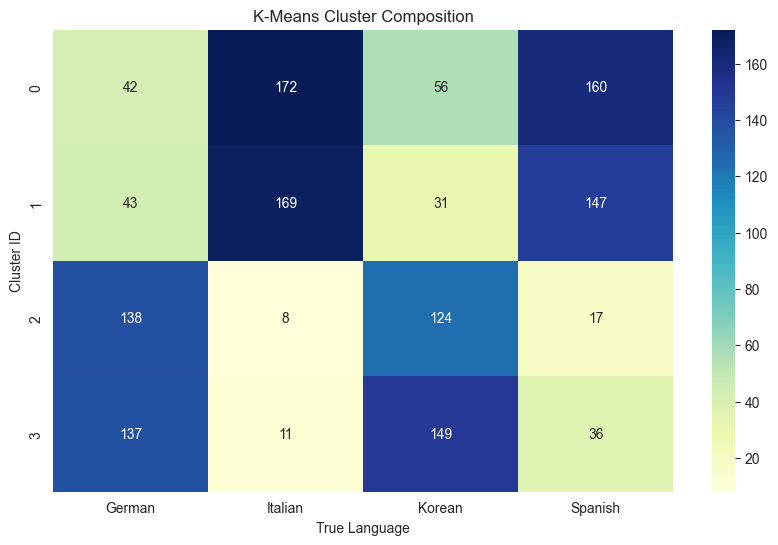

K-Means Cluster Composition - Purity: 0.4361


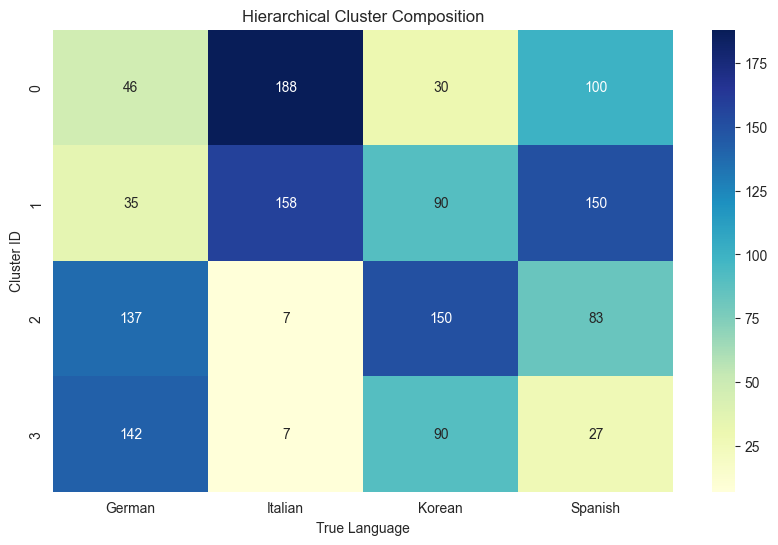

Hierarchical Cluster Composition - Purity: 0.4431


In [28]:
def plot_cluster_composition(cluster_col, title):
    contingency = pd.crosstab(df_cluster[cluster_col], df_cluster['label'])
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(contingency, annot=True, fmt='d', cmap='YlGnBu')
    plt.title(title)
    plt.xlabel('True Language')
    plt.ylabel('Cluster ID')
    plt.show()
    
    purity = np.sum(contingency.max(axis=1)) / df_cluster.shape[0]
    print(f"{title} - Purity: {purity:.4f}")

plot_cluster_composition('kmeans_cluster', 'K-Means Cluster Composition')
plot_cluster_composition('agg_cluster', 'Hierarchical Cluster Composition')
